### 4.6 RBA Policy Classifier — seven readings of one decision

$$\text{action} = \begin{cases}\text{cut} & \hat y < 2.0 \\ \text{hike} & \hat y > 3.0 \\
\text{hold} & \text{otherwise}\end{cases} \qquad
i^{*} = r^{*} + \pi + \varphi_\pi(\pi-2.5) + \varphi_u\,\Delta u_{t-1} \qquad
P(Y\le j) = F(\theta_j - x'\beta)$$

left to right: the transparent **threshold** baseline (reportable, macro-F1 0.775); the
**Taylor rule** (fixed and estimated variants); **ordered logit/probit** ($F$ = logistic or
$\Phi$). Frank–Hall XGBoost decomposes the same ordinal target into $K{-}1$ cumulative
binary classifiers; majority vote takes the mode of the first four, tie-broken by
threshold's own call.

*Source: `src/models/rba_classifier.py`, served at `GET /rba-action`*

#### Explained, step by step

**1. The threshold baseline (the reportable model)**

$$\text{action} = \begin{cases}\text{cut} & \hat y < 2.0 \\ \text{hike} & \hat y > 3.0 \\ \text{hold} & \text{otherwise}\end{cases}$$

The simplest possible classifier: take the headline CPI forecast $\hat y$ and check which side of the RBA's own 2-3% target band it falls on. Below the band $\to$ room to cut; above the band $\to$ pressure to hike; inside the band $\to$ hold. No fitted parameters at all — pure domain knowledge (the RBA's published target range) wired directly into a rule. It's also the one that's actually reportable (macro-F1 = 0.775), beating every fitted alternative below.

**2. Taylor rule**

$$i^{*} = r^{*} + \pi + \varphi_\pi(\pi-2.5) + \varphi_u\,\Delta u_{t-1}$$

A classic monetary-policy formula for a "textbook" target interest rate $i^*$. $r^*$ is the assumed neutral real interest rate; adding current inflation $\pi$ converts it to a nominal rate. $\varphi_\pi(\pi - 2.5)$ is a correction: if inflation is above the 2.5% target midpoint, this term is positive and pushes $i^*$ up (tighten); if below, it pushes $i^*$ down. $\varphi_u\,\Delta u_{t-1}$ adds a reaction to last quarter's *change* in unemployment — rising unemployment typically pushes the prescribed rate down. $\varphi_\pi$ and $\varphi_u$ are sensitivity coefficients, either fixed at textbook values or estimated from the data (the app's two Taylor-rule variants).

**3. Ordered logit / probit**

$$P(Y\le j) = F(\theta_j - x'\beta)$$

These treat the three outcomes (cut < hold < hike) as **ordered**, not just three unrelated labels — the model knows "hike" is "further" from "cut" than "hold" is. $x'\beta$ is a linear combination of predictors; $\theta_j$ are estimated **cutpoints** on that underlying score scale; $F$ converts the raw score into a probability between 0 and 1 — the logistic CDF for **ordered logit**, or $\Phi$, the standard normal CDF, for **ordered probit**. The formula reads: "the probability the outcome is category $j$ or lower equals the probability the underlying score $x'\beta$, plus noise, falls below cutpoint $\theta_j$." Subtracting consecutive cumulative probabilities gives each individual class's probability.

The remaining models mentioned above — Frank-Hall XGBoost decomposing the ordinal target into $K{-}1$ cumulative binary classifiers, and majority vote taking the mode of the first four models' calls — combine these same probability outputs differently rather than introducing new formulas.

Forecast origin 2025Q4 → target 2026Q1: reportable call is 'hike' (threshold)


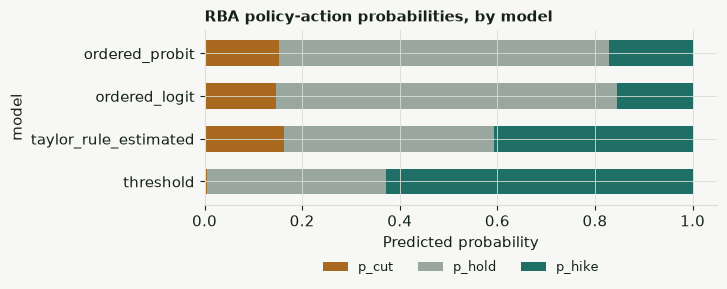

In [46]:
rba = pd.read_csv(PROJECT_ROOT / "reports/tableau/rba_action.csv")
print(f"Forecast origin {rba['forecast_origin'].iloc[0]} → target {rba['target_quarter'].iloc[0]}: "
      f"reportable call is '{rba['reportable_action'].iloc[0]}' ({rba['reportable_model'].iloc[0]})")
probs = rba.dropna(subset=["p_cut"]).set_index("model")[["p_cut", "p_hold", "p_hike"]]

fig, ax = plt.subplots(figsize=(7.4, 3.2))
probs.plot(kind="barh", stacked=True, ax=ax, color=[HIGHLIGHT, "#9aa79f", ACCENT], width=0.6)
ax.set_xlabel("Predicted probability")
ax.set_title("RBA policy-action probabilities, by model", loc="left", fontsize=11, fontweight="bold")
ax.legend(frameon=False, ncol=3, fontsize=9, loc="upper center", bbox_to_anchor=(0.5, -0.25))
fig.tight_layout()
plt.show()

```{tip}
The table and chart above are the same pinned `reports/tableau/rba_action.csv` fallback the Streamlit app itself shows when the live API isn't reachable. To refresh against the live `/rba-action` endpoint instead, run `streamlit run app/streamlit_app.py` from the project root, open **4.6 RBA Policy Classifier**, and press **Refresh RBA action**.
```